# EE P595 Homework 1 Supplementary Material

This is a supplementary material for our first homework. It covers all extra algorithms not mentioned in the second lab and lecture, and focuses more on the details of these algorithms rather than API usage. Most of the algorithms come with formulas that describe how themselves or their loss is computed. If you are not confortable with mathametic details just skip them, as you don't need to understand them to finish the homework. We hope that this supplementary material can serve as a reference for your first homework, as well as a brief introduction to basic traditional machine learning should you decide to go deeper.

## TF-IDF

**TF-IDF** is the abbreviation for **term frequency–inverse document frequency**, and is defined as the product of two frequency, . The most classical version of TF-IDF is:

$$
tf-idf(t, d, D) = tf(t, d) \cdot idf(t, D) = \frac{f_{t,d}}{|d|} \log \frac{|D|}{|D_t|}
$$

Where $t$ is the term, $D$ is the collection of all documents, $d$ is one of the document that contains $t$ and $D_t$ is the subset of documents that contains term $t$. The advantage of TF-IDF is that frequent and useless words, such as "the", "a" and "an" will receive lower weight, since they appear in almost all documents. On the other hand, unique yet frequent (in any single document, i.e. $d \in D_t$) words will get higher weight. Research has shown that TF-IDF is easy to implement and performs relatively well.

Here we show an example of TF-IDF. Let's consider a collection of 2 documents:

|Word  |Count|
|------|-----|
|this  |1    |
|is    |1    |
|a     |2    |
|sample|1    |

|Word   |Count|
|-------|-----|
|this   |1    |
|is     |1    |
|another|2    |
|example|3    |

Now let's compute the TF-IDF of "is" and "example" for each document:

$$
tf-idf("this", d_1, D) = tf("this", d_1) \cdot idf("this", D) = \frac{1}{5} \log \frac{2}{2} = 0.2 \times 0 = 0 \\
tf-idf("this", d_2, D) = tf("this", d_2) \cdot idf("this", D) = \frac{1}{7} \log \frac{2}{2} = \frac{1}{7} \times 0 = 0
$$

$$
tf-idf("example", d_1, D) = tf("example", d_1) \cdot idf("example", D) = \frac{0}{5} \log \frac{2}{1} \approx 0 \times 0.301 = 0 \\
tf-idf("example", d_2, D) = tf("example", d_2) \cdot idf("example", D) = \frac{3}{7} \log \frac{2}{1} \approx 0.429 \times 0.301 = 0.129
$$

# Character N-gram
A **character N-gram** consists of N consecutive characters for a character sequence. Usually, 1-gram is referred to as unigram, 2-gram as bigram, 3-gram as trigram. Below is an example showing all character 1, 2, 3 and 4-grams for word "cold":

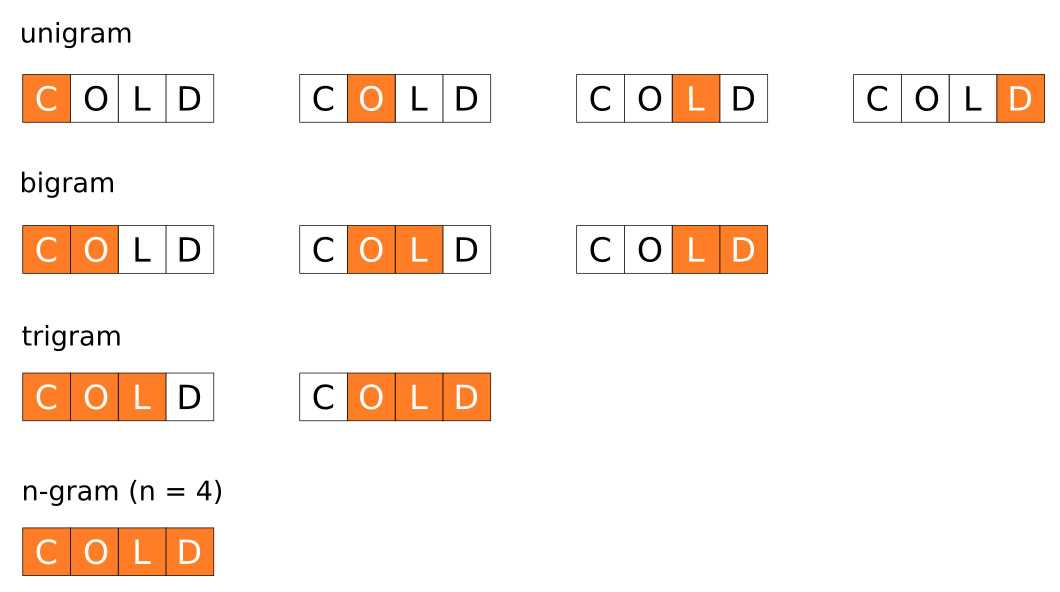

## Ridge Regression
Ridge regression is a variant of linear regression algorithm with L2 normalization. During training, we minimize the following ridge loss:

$$
l_{ridge} = ||\mathbf{y} - \mathbf{X} \mathbf{w}||_2^2 + \beta ||\mathbf{w}||_2^2
$$

where $y$ is a vector derived from labels, $\mathbf{X}$ is a matrix container a number of feature vectors, $\beta$ is regularization factor and $\mathbf{w}$ is a trainable weight vector. We have assumed that $\mathbf{X}$ here is demeaned (subtracted by the mean of original $\mathbf{X}$, denoted as $\overline{\mathbf{X}}$) and omit the bias term $\mathbf{b}$. In binary classification, we map the true label to $y = 1$ and false label to $y = -1$. The classification results for new samples are then determined by:

$$
\mathbf{y}_{pred} = sign(\mathbf{X} \mathbf{w})
$$

Compared to regular linear regression, term $\beta ||\mathbf{w}||_2^2$ is unique to ridge regression and is called regularization term. Ridge regression is more robust then regular linear regression, as it handles cases where collinearity exists between different dimensions of feature vectors, while regular linear regression fails because $\mathbf{X}$ isn't full rank and it requires the inverse of $\mathbf{X}$ to compute $\mathbf{w}$.

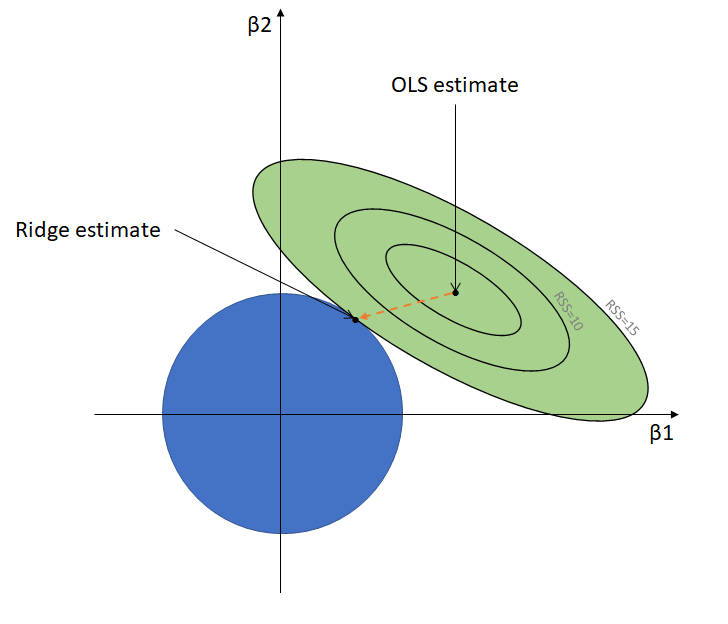

## SVM
(Linear) SVM is a popular algorithm for binary classification. The linear SVM algorithm treats the feature vector of each sample as a point in the linear space, and tries to find a hyperplane that separates points of the two classes as good as possible. This is done by ensuring each sample resides at corresponding side of the "maximum-margin" hyperplane:

$$
\min \mathbf{w} \ s.t. y_i(\mathbf{w}^T \mathbf{x}_i - b) \ge 1 \ \forall i = 1 \cdots N
$$

The classification result is determined by:

$$
y_{pred} = sign(1 - \mathbf{w}^T \mathbf{x} - b)
$$

When all points can be separated to their corresponding sides, we say the features are linearly separatable. However, real world features are complex and may not be linearly separatable and in this case, we use hinge loss. By default, `scikit-learns`'s SVM implementation also use L2 regularization and sequred hinge loss, so it's loss can be written as follows:

$$
l_{hinge} = \max(0, \frac{1}{N} \sum_{i=1}^N y_i(1 - \mathbf{w}^T \mathbf{x}_i - b)^2 + \beta ||\mathbf{w}||_2^2
$$

Hinge loss penalize cases where $y_i$ is not in the correct side of the hyperplane. The classification result is determined the same way as above.

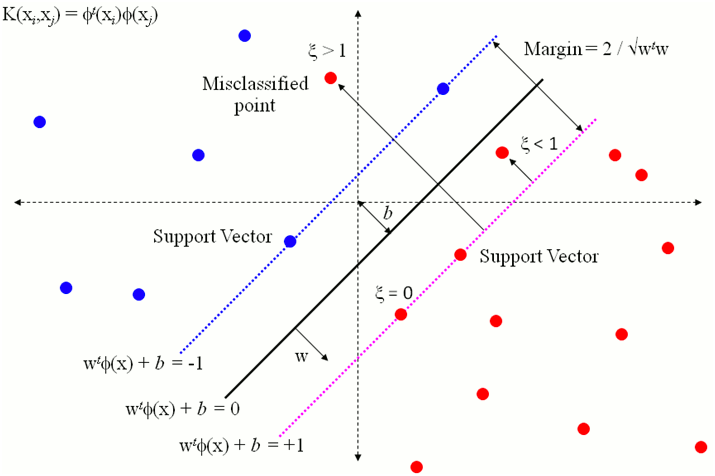

## Lasso
Lasso regression is a variant of linear regression algorithm with L1 normalization. Lasso regression loss looks very similar to ridge regression loss, except the regularization term uses 1 norm:

$$
l_{Lasso} = ||\mathbf{y} - \mathbf{X} \mathbf{w}||_2^2 + \alpha ||\mathbf{w}||_1
$$

Due to the properties of 1 norm, Lasso regression prefers sparse $\mathbf{w}$ and is useful for performing linear regression with feature selection. The larger $\alpha$ is, the sparser $\mathbf{w}$ will be. The regularization term of Lasso makes $\mathbf{w}$ intractable and in practice we use iterational algorithm to approximately solve $\mathbf{w}$.

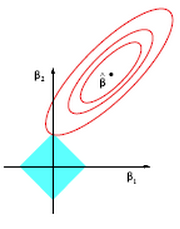

## ElasticNet
ElasticNet regression is a variant of linear regression algorithm with both L1 and L2 normalization. It "combines" the regularization term of both ridge and Lasso regression and hence possesses the advantage of both. ElasticNet loss is defined as follows:

$$
l_{ElasticNet} = ||\mathbf{y} - \mathbf{X} \mathbf{w}||_2^2 + \alpha ||\mathbf{w}||_1 + (1 - \alpha) ||\mathbf{w}||_2^2
$$

You shuold use ElasticNet regression when prior knowledge of features is unknown.

## Kernel method
Kernel method is a class of algorithms that makes use of kernel functions. With kernel functions, we implictly map sample features (represented as points) into a higher-dimensional space, where the inner product of transformed sample features can be efficiently computed using the kernel function. Kernel method can be used in conjunction with linear regression algorithm or its varients to deal with non-linear mapping. It can also be used with SVM to make sample features linear serapable in an alternative space.

Kernel functions are usually non-linear functions and must satisfy [Mercer's Theorm](https://en.wikipedia.org/wiki/Mercer%27s_theorem), which requires them to be symmetric positive-semidefinite functions. Here we introduce two most common kernel functions:

* Polynomial kernel: suppose we have two sample vector $\mathbf{x}$ and $\mathbf{y}$, then the polynomial kernel function $K(\mathbf{x}, \mathbf{y})$ is defined as:

$$
K(\mathbf{x}, \mathbf{y}) = (\mathbf{x}^T \mathbf{y} + c)^d
$$

Where $c \ge 0$ is a constant controlling the influence of each dimension and $d$ determines number of dimension of the transformed space.

* Radial basis function (RBF) kernel: a radial basis function kernel is defined as:

$$
K(\mathbf{x}, \mathbf{y}) = \exp(\frac{-||\mathbf{x} - \mathbf{y}||_2^2}{2 \sigma^2})
$$

Where $\sigma$ is a hyper-parameter. RBF kernel corresponds to an infinite dimension transformed space.

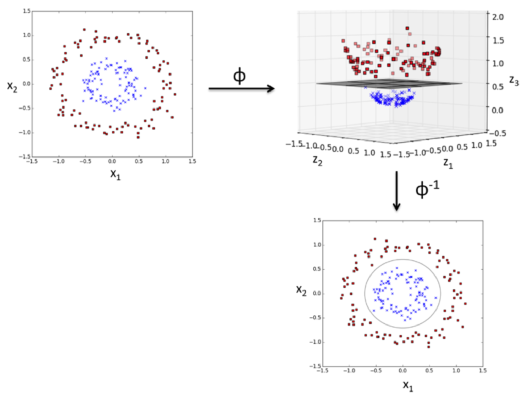

## References

1. TF-IDF: https://en.wikipedia.org/wiki/Tf%E2%80%93idf
2. N-grams: https://en.wikipedia.org/wiki/N-gram
3. Ridge regression: https://en.wikipedia.org/wiki/Tikhonov_regularization
4. SVM: https://en.wikipedia.org/wiki/Support-vector_machine
5. Lasso: https://en.wikipedia.org/wiki/Lasso_(statistics)
6. ElasticNet: https://en.wikipedia.org/wiki/Elastic_net_regularization
7. Kernel method: https://en.wikipedia.org/wiki/Kernel_method
8. Mercer's theorm: https://en.wikipedia.org/wiki/Mercer%27s_theorem